#機械学習の勉強

In [2]:
import pandas as pd
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\iris.csv')
df.head(3)

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
0,0.22,0.63,0.08,0.04,Iris-setosa
1,0.17,0.42,0.35,0.04,Iris-setosa
2,0.11,0.50,0.13,0.04,Iris-setosa


In [3]:
df['種類'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [4]:
syurui=df['種類'].unique()
syurui[0]

'Iris-setosa'

In [5]:
df['種類'].value_counts()

種類
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
df.tail(3)

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
147,0.61,0.42,NaN,0.79,Iris-virginica
148,0.53,0.58,0.63,0.92,Iris-virginica
149,0.44,0.42,0.41,0.71,Iris-virginica


In [7]:
df.isnull()

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,True,False,False
148,False,False,False,False,False


In [8]:
#|axis| 0は列ごと | 1は行ごと |
df.isnull().any(axis=0)

がく片長さ     True
がく片幅      True
花弁長さ      True
花弁幅       True
種類       False
dtype: bool

In [9]:
df.sum()

がく片長さ                                                62.29
がく片幅                                                 65.62
花弁長さ                                                 72.04
花弁幅                                                  66.22
種類       Iris-setosaIris-setosaIris-setosaIris-setosaIr...
dtype: object

In [10]:
tmp=df.isnull()
tmp.sum()

がく片長さ    2
がく片幅     1
花弁長さ     2
花弁幅      2
種類       0
dtype: int64

In [11]:
(df.isnull()).sum()

がく片長さ    2
がく片幅     1
花弁長さ     2
花弁幅      2
種類       0
dtype: int64

In [12]:
df.tail(3).isnull().any(axis=1)

147     True
148    False
149    False
dtype: bool

In [13]:
df2=df.dropna(how='any',axis=0) #dropnaは非破壊関数なので新たな変数に代入
df2.tail(3)

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
146,0.56,0.21,0.69,0.46,Iris-virginica
148,0.53,0.58,0.63,0.92,Iris-virginica
149,0.44,0.42,0.41,0.71,Iris-virginica


In [14]:
df.isnull().any(axis=0)

がく片長さ     True
がく片幅      True
花弁長さ      True
花弁幅       True
種類       False
dtype: bool

In [15]:
print(df2.isnull().any(axis=0))

がく片長さ    False
がく片幅     False
花弁長さ     False
花弁幅      False
種類       False
dtype: bool


In [16]:
#欠損値の穴埋め
df['花弁長さ']=df['花弁長さ'].fillna(0)
df.tail(3)

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
147,0.61,0.42,0.00,0.79,Iris-virginica
148,0.53,0.58,0.63,0.92,Iris-virginica
149,0.44,0.42,0.41,0.71,Iris-virginica


In [17]:
ave=sum(df['花弁長さ'])/len(df['花弁長さ'])
print(ave)

0.48026666666666673


In [18]:
df.mean(numeric_only=True)

がく片長さ    0.420878
がく片幅     0.440403
花弁長さ     0.480267
花弁幅      0.447432
dtype: float64

In [19]:
df['がく片長さ'].mean()

np.float64(0.42087837837837844)

In [20]:
df.std(numeric_only=True)

がく片長さ    0.228910
がく片幅     0.181137
花弁長さ     0.236909
花弁幅      0.309960
dtype: float64

In [21]:
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\iris.csv')
colmean=df.mean(numeric_only=True)

#平均値で欠損値を穴埋めしてdf2に代入
df2=df.fillna(colmean)

#欠損値の確認
df2.isnull().any(axis=0)

がく片長さ    False
がく片幅     False
花弁長さ     False
花弁幅      False
種類       False
dtype: bool

In [22]:
xcol=['がく片長さ','がく片幅','花弁長さ','花弁幅']
x=df2[xcol]
t=df2['種類']

In [23]:
from sklearn import tree
model=tree.DecisionTreeClassifier(max_depth=2,random_state=0)


In [24]:
model.fit(x,t)
model.score(x,t)

0.94

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,t,test_size=0.3,random_state=0)

In [26]:
print(x_train.shape)
print(x_test.shape)

(105, 4)
(45, 4)


In [28]:
display(x_test)

,がく片長さ,がく片幅,花弁長さ,花弁幅
114,0.420000,0.33,0.50,0.960000
62,0.470000,0.08,0.32,0.380000
33,0.330000,0.92,0.44,0.040000
107,0.830000,0.38,0.71,0.710000
7,0.190000,0.58,0.47,0.040000
100,0.560000,0.54,0.88,0.447432
40,0.190000,0.63,0.18,0.080000
86,0.670000,0.46,0.49,0.580000
76,0.690000,0.33,0.72,0.540000
71,0.500000,0.33,0.41,0.500000


In [29]:
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9555555555555556

In [30]:
import pickle
with open('irismodel.pkl','wb') as f:
    pickle.dump(model,f)

In [31]:
model.tree_.feature

array([ 3, -2,  3, -2, -2])

In [33]:
model.tree_.threshold

array([ 0.275, -2.   ,  0.69 , -2.   , -2.   ])

In [34]:
print(model.tree_.value[1])
print(model.tree_.value[3])
print(model.tree_.value[4])

[[1. 0. 0.]]
[[0.         0.83783784 0.16216216]]
[[0.         0.02941176 0.97058824]]


In [35]:
print(model.tree_.n_node_samples[1])

34


In [36]:
print(model.tree_.value[1])
print(model.tree_.n_node_samples[1])
print(model.tree_.value[1] * model.tree_.n_node_samples[1])

[[1. 0. 0.]]
34
[[34.  0.  0.]]


In [38]:
model.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

[Text(0.4, 0.8333333333333334, 'koben_haba <= 0.275\ngini = 0.664\nsamples = 105\nvalue = [34, 32, 39]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'koben_haba <= 0.69\ngini = 0.495\nsamples = 71\nvalue = [0, 32, 39]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.272\nsamples = 37\nvalue = [0, 31, 6]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]')]

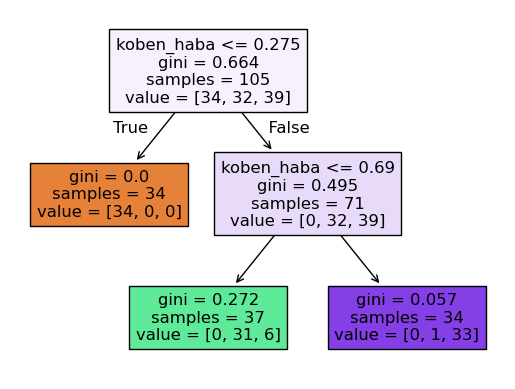

In [ ]:
x_train.columns=['gaku_nagasa','gaku_haba','kaben_nagasa','kaben_haba']
from sklearn.tree import plot_tree
plot_tree(model,feature_names=x_train.columns,filled=True)